In [1]:
from resources.imports import *

from resources.lattices import Geometry, calcC_mohr, calcC_sims, plot_IsotropyVariation, calc_IsoEffProperties, effProperties, \
                                calc_anisoParams

In [14]:
LAT = "FCC"
dis = 'disNodes'

# TOOD: Check homogenization sims for all lattice topologies.

# Truss Axial Plasticity Method

In [15]:
l = 0.01
nnx = 10

geom = Geometry(LAT, l, nnx)

In [16]:
Cs_mohr = calcC_mohr(copy.deepcopy(geom), "lattice", dis=dis, count=20, plot=False)
C_per = Cs_mohr[0]
Cunit_mohr = calcC_mohr(copy.deepcopy(geom), "unit", plot=False)[0]

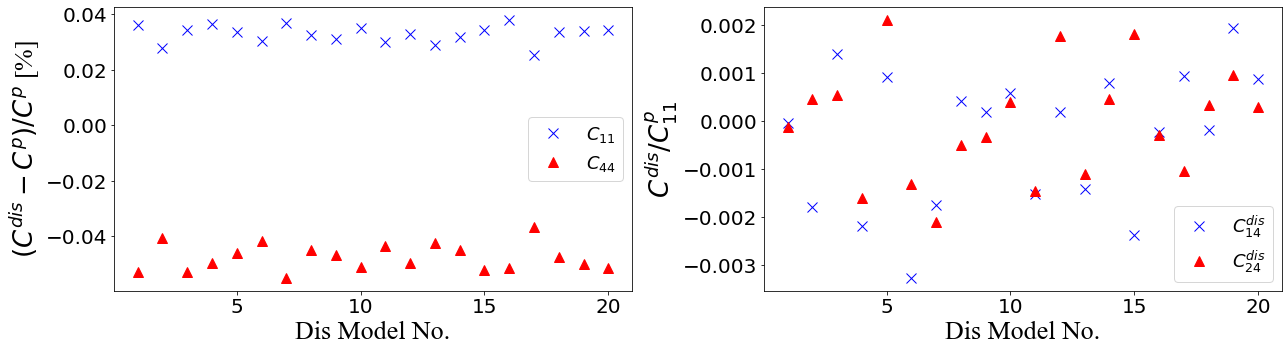

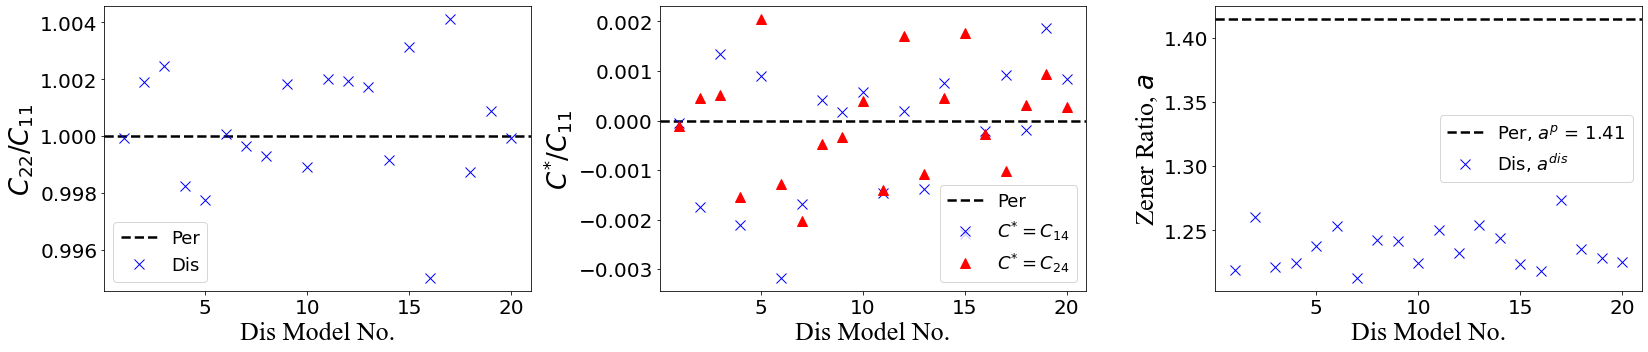

In [17]:
plot_IsotropyVariation(Cs_mohr, stiff=True, paper=True)

In [6]:
E_eff, v_eff, iso = calc_IsoEffProperties(Cunit_mohr)
E_eff, v_eff, iso

(8200000000.0, 0.3333333333333333, True)

In [7]:
effProperties(LAT)

(1476000000.0000002, 1, 1484013673.8387294, 1.0108586366378445)

In [8]:
Cunit_mohr

array([[ 9.225e+09,  3.075e+09,  0.000e+00],
       [ 3.075e+09,  9.225e+09,  0.000e+00],
       [ 0.000e+00, -0.000e+00,  3.075e+09]])

In [9]:
lambda_aniso, rho_aniso = calc_anisoParams(C=Cunit_mohr)
lambda_aniso, rho_aniso

(1.0000000000000002, 1.0)

In [10]:
v_eff = 1/3
C_iso_pStress = (1/(1-v_eff**2))*np.array([[1, v_eff, 0],
                                           [v_eff, 1, 0],
                                           [0, 0, (1-v_eff)/2]])
C_iso_pStrain = (1/((1-2*v_eff)*(1+v_eff)))*np.array([[1-v_eff, v_eff, 0],
                                                      [v_eff, 1-v_eff, 0],
                                                      [0, 0, (1-2*v_eff)/2]])

np.around(C_iso_pStress/min(C_iso_pStress[0][:2]),2), np.around(C_iso_pStrain/min(C_iso_pStrain[0][:2]))

(array([[3., 1., 0.],
        [1., 3., 0.],
        [0., 0., 1.]]),
 array([[2., 1., 0.],
        [1., 2., 0.],
        [0., 0., 1.]]))

# Beam-Based Homogenization Method

In [11]:
nnx = 20
if LAT.lower() == "tri":
    nnx = 30

Cs_sims = calcC_sims(LAT, nnx, dis=dis, count=0, pDir=r"Z:\p1\sims\Ti\stiffMatrix\Cmatrix-periodic\\")

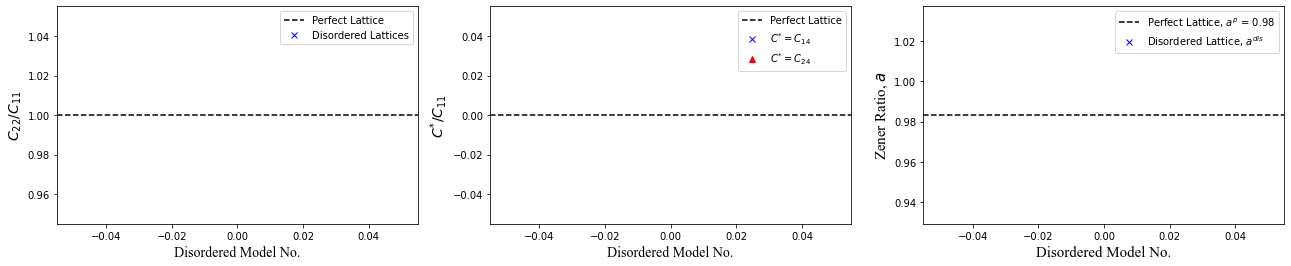

In [12]:
plot_IsotropyVariation(Cs_sims, paper=True)